# Insper - Modelagem e Simulação do Mundo Físico

## Atividade - Gráficos conclusivos

----

### Introdução

A cintilografia é um exame diagnóstico que avalia a função e a forma dos órgãos por meio da injeção de pequena quantidade de uma substância radioativa chamada radiofármaco. Essa substância emite radiações para as câmeras e computadores, que são transformadas em imagens coloridas, permitindo calcular a concentração e a velocidade de difusão da substância em diferentes partes do corpo.
Na cintilografia da tireoide, utiliza-se o $I-131$, um isótopo radioativo do iodo. Faz-se a aplicação intravenosa de certa quantidade, medida em $\mu Ci$ (micro Curie, ou seja, $10^{-6}$ Curie, sendo o Curie ($Ci$) uma unidade de medida de radioatividade), de iodeto de sódio radioativo ($NaI$). 
A partir daí, a concentração de $NaI$ é monitorada no sangue, na tireoide e no resto do corpo. Sabe-se que parte da substância inicialmente presente no sangue é absorvida pela tireoide, sendo o restante eliminado pela urina. O $NaI$ da tireoide passa, então, para o resto do corpo, de onde é eliminado pelas fezes ou devolvido ao sangue. Dessa forma, a modelagem do processo de cintilografia da tireoide pode ser feita considerando-se três compartimentos: sangue, tireoide e resto do corpo. 
Para simplificar a modelagem matemática, porém, vamos considerar apenas dois compartimentos, o sangue e a tireoide. Com isso, temos o seguinte diagrama de estoques e fluxos, em que todas as constantes indicadas são dadas em $dia^{-1}$.

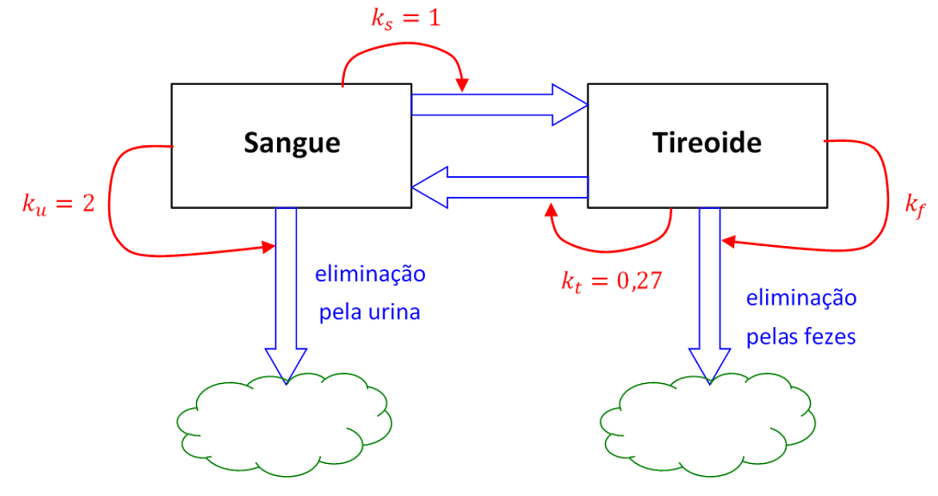

Note que os valores dos parâmetros $k_u$, $k_s$ e $k_t$ foram fornecidos, mas não o valor do parâmetro $k_f$. Esse último será determinado na validação, que faremos mais à frente.

Nesta atividade, vamos implementar esse modelo em Python, validá-lo a partir de dados reais e, em seguida, gerar gráficos conclusivos. Antes de iniciar, vamos já importar todas as bibliotecas que serão utilizadas nessa atividade, assim não precisamos as importar novamente. Para tal, basta rodar o código abaixo antes de ir para o próximo item.

In [82]:
# Importa bibliotecas necessárias
from scipy.integrate import odeint
import math as m 
import numpy as np
import matplotlib.pyplot as plt

----

### Item 1 - Implementação

#### a) Equações diferenciais

Escreva em um papel as equações diferenciais do modelo. Use a letra $S$ para representar o estoque do sangue e a letra $T$ para representar o da tireoide.

#### b) Modelo

Em seguida, declare no espaço a seguir as constantes do problema e implemente uma função denominada `modelo` que recebe uma lista com os estoques $x = [S \quad T]$ e o instante de tempo $t$ e retorna uma lista com as taxas de variação dos estoques $\frac{dx}{dt} = [\frac{dS}{dt} \quad \frac{dT}{dt}]$. Lembre-se que, mesmo que sua função não utilize a variável $t$, ela é obrigatória para o correto funcionamento da função `odeint`.

Como dito anteriormente, o valor de $k_f$ será determinado posteriormente. Porém, como você vai precisar desse valor para definir a função `modelo`, vamos começar "chutando" que ele vale $0,3$.

In [75]:
ks=1
ku=2
kt=0.27
kf=0.13

def modelo(x,t):
    S=x[0]
    T=x[1]
    dSdt=kt*T-ks*S-ku*S
    dTdt=ks*S-kt*T-kf*T
    return [dSdt,dTdt]

#### c) Solução numérica

Agora que você implementou a função `modelo`, execute a função `odeint` e em seguida plote **em uma mesma figura** os gráficos das soluções $S(t)$ e $T(t)$. Para isso, você vai precisar de:

- Uma lista com as condições iniciais $S(0) = 1 \, \mu Ci/dL$ e $T(0) = 0 \, \mu Ci/dL$
- Uma lista de tempo de $0$ a $10$ $dias$ com $\Delta t=10^{-3}$ $dia$

**Observação:** $\mu Ci/dL$ é uma unidade de medida, assim como $dia$ ou $kg$. Todos os valores de parâmetros nessa atividade têm unidades compatíveis, de modo que não é necessário fazer conversões.

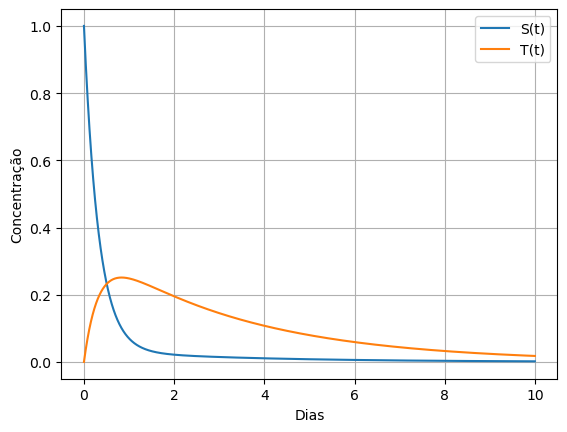

In [76]:
t=np.arange(0,10,1e-3)
funcao=odeint(modelo,[1,0],t)
S_t=funcao[:,0]
T_t=funcao[:,1]
plt.plot(t,S_t,label="S(t)")
plt.plot(t,T_t,label="T(t)")
plt.xlabel("Dias")
plt.ylabel("Concentração")
plt.grid()
plt.legend()


----

### Item 2 - Validação

Seus professores estavam revirando as gavetas e encontraram o seguinte gráfico, feito na época em que as figuras eram impressas em papel, em vez de salvas no computador:

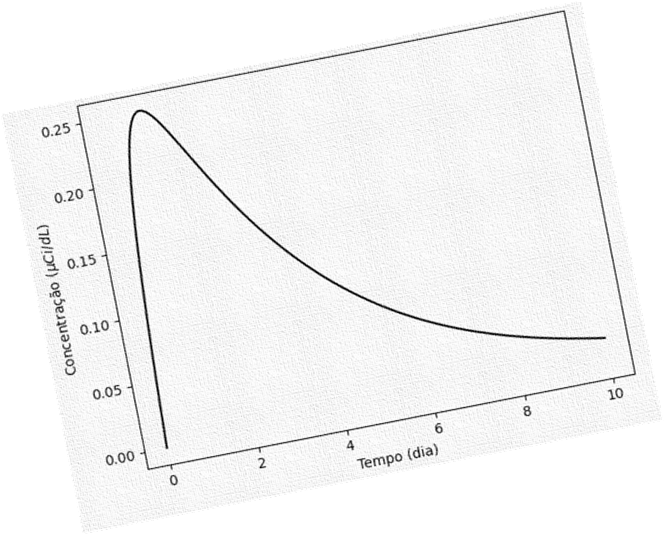

Esse gráfico exibe **dados experimentais da concentração na tireoide** nas mesmas condições da simulação que você fez no **Item 1c**. Será que os valores do seu gráfico e do gráfico acima correspondem? Para responder a essa pergunta, seria interessante plotar o seu gráfico e esse em uma mesma figura, não?

Felizmente, existe um aplicativo chamado Web Plot Digitizer. Veja o vídeo disponível nesse [link](https://youtu.be/IK820ABRAdM) para aprender a utilizar!

#### a) Importação dos dados experimentais
Após ver o vídeo, digitalize os dados do gráfico acima e plote-os na mesma figura que os dados que você obteve no **Item 1c**.

**Para ajudar, veja os comentários do código abaixo.**

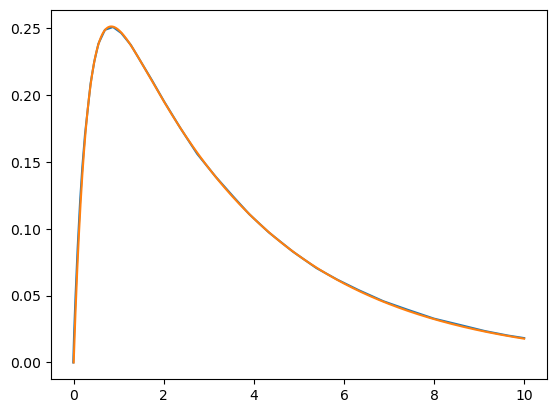

In [77]:
dados = np.loadtxt('grafico2.csv', delimiter=';')
t_lista_digitalizada = dados[:,0] 
T_lista_digitalizada = dados[:,1]

plt.plot(t_lista_digitalizada, T_lista_digitalizada)
plt.plot(t, T_t)

#### b) Determinação do parâmetro $k_f$

Você deve ter notado que os dados do modelo não correspondem aos dados experimentais. Isso ocorreu porque o valor de $k_f$ que havíamos "chutado" no **item 1b** estava incorreto.

Para obter o valor correto, **execute novamente os itens 1b, 1c e 2a (sequencialmente), mudando o valor de $k_f$ a cada execução**. Faça isso até que os dados gerados pelo modelo e os dados experimentais tenham boa concordância.

Após fazer isso, confirme o valor com seu professor.

----

### Item 3 - Gráficos conclusivos

Agora que validamos nosso modelo, vamos gerar alguns gráficos conclusivos.

#### a) Influência de um parâmetro 


Implemente novamente a função `modelo` com um novo nome, porém, dessa vez, essa função **também deve receber** o parâmetro $k_t$ (transmissão da tireoide para o sangue), o qual não será mais considerado uma variável global. O valor de $k_f$ é o obtido após a validação do item anterior.

Em seguida, resolva o sistema 8 vezes consecutivas, uma para cada um dos seguintes valores de $k_t$, plotando **apenas** a solução $T(t)$ em uma mesma figura para os 8 casos:

**<center> 0.1 ; 0,2 ; 0.3 ; ... ; 0,7 ; 0,8 </center>**

Text(0, 0.5, 'COncentração')

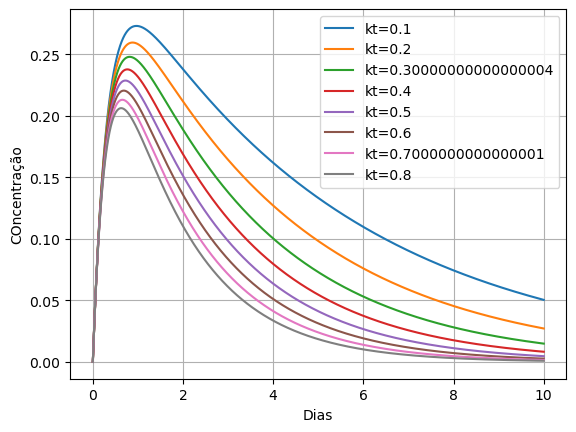

In [78]:
def modelo2(x,t,kt):
    S=x[0]
    T=x[1]
    dSdt=kt*T-ks*S-ku*S
    dTdt=ks*S-kt*T-kf*T
    return [dSdt,dTdt]

kt_lista=np.arange(0.1,0.9,0.1)

for kt in kt_lista:
    x=odeint(modelo2,[1,0],t,args=(kt,))
    T_t=x[:,1]
    plt.plot(t,T_t,label=f"kt={kt}")
plt.legend()
plt.grid()
plt.xlabel("Dias")
plt.ylabel("COncentração")
    
    
    
    

#### b) Gráfico conclusivo

Você notou que a concentração máxima na tireoide muda para diferentes valores de $k_t$? Para visualizar essa variação de maneira mais clara, vamos fazer um novo tipo de gráfico, que chamamos de **gráfico conclusivo** em ModSim e que será um dos aspectos avaliados nos Projetos 2 e 3. Para entender melhor, assista ao vídeo disponível nesse [link](https://youtu.be/LT3e5PPlQxM).

Usando a mesma função que você implementou no item anterior, resolva novamente o sistema para os 8 diferentes valores de $k_t$. Porém, dessa vez, em vez de plotar a solução ao longo do tempo, você deverá registrar o **maior valor atingido por $T(t)$** em cada uma das execuções. Em seguida, plote um gráfico que relacione esses valores máximos a cada um dos valores de $k_t$.

- Você pode usar a função `max()` para obter o valor máximo de uma lista.

- Guarde esses valores máximos em uma lista.

- Por fim, plote o gráfico conclusivo, ou seja, o gráfico com os valores de $k_t$ no eixo das abscissas e os correspondentes valores máximos de $T(t)$ no eixo das ordenadas.

Text(0, 0.5, 'Concentração máxima na tireoide ($\\mu Ci/dL$)')

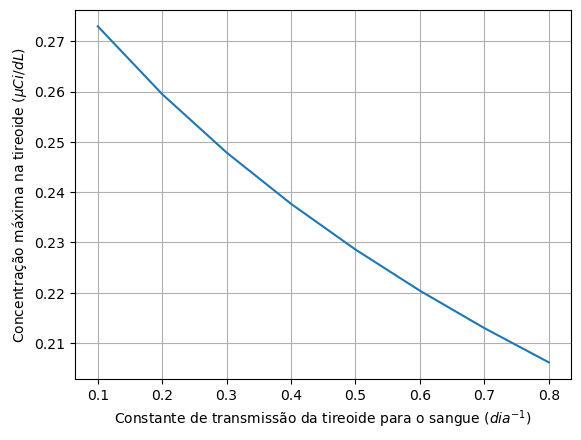

In [79]:
picos=[]
for kt in kt_lista:
    x=odeint(modelo2,[1,0],t,args=(kt,))
    T_t=x[:,1]
    i=0
    maior=T_t[0]
    while i<len(T_t):
        if T_t[i]>maior:
            maior=T_t[i]
        i+=1 
    picos.append(maior)

plt.plot(kt_lista,picos)
plt.grid()
plt.xlabel("Constante de transmissão da tireoide para o sangue ($dia^{-1}$)")
plt.ylabel("Concentração máxima na tireoide ($\\mu Ci/dL$)")

#### c) Outro gráfico conclusivo

Agora, em vez de registrar a concentração máxima atingida na tireoide para cada valor de $k_t$, vamos registrar o **instante de tempo em que essa concentração máxima é atingida**.

Copie e cole seu código do item anterior e adapte-o para que, em vez de guardar as concentrações máximas em uma lista, sejam guardados os intantes em que essas concentrações são máximas.

Text(0, 0.5, 'Tempo ($dia$)')

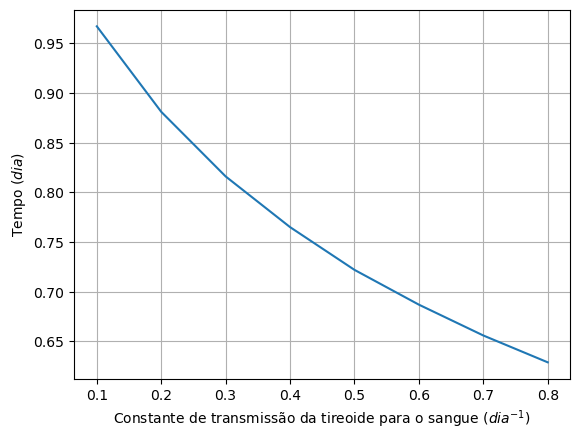

In [80]:
picos_t=[]
for kt in kt_lista:
    x=odeint(modelo2,[1,0],t,args=(kt,))
    T_t=x[:,1]
    i=0
    maior=T_t[0]
    while i<len(T_t):
        if T_t[i]>maior:
            maior=T_t[i]
            t_max=t[i]
        i+=1 
    picos_t.append(t_max)

plt.plot(kt_lista,picos_t)
plt.grid()
plt.xlabel("Constante de transmissão da tireoide para o sangue ($dia^{-1}$)")
plt.ylabel("Tempo ($dia$)")


----

### Item 4 - Solução analítica (opcional)

#### a) Solução analítica

De modo geral, encontrar as soluções analíticas de um sistema de equações diferenciais é uma tarefa bastante trabalhosa e, por vezes, impossível. Porém, existem situações em que isso é possível, como você verá com mais detalhes em Matemática da Variação. Uma dessas situações ocorre quando as expressões que descrevem as derivadas (no nosso caso, $\frac{dS}{dt}$ e $\frac{dT}{dt}$) são do primeiro grau nas variáveis dependentes (no nosso caso, $S$ e $T$).

Em casos como esse, a solução pode ser obtida por meio de conhecimentos de Álgebra Matricial (finalmente, as tais matrizes terão alguma utilidade!). Considerando os dados do nosso problema, as soluções analíticas são:

$$ S(t)=\frac{27}{28}\cdot e^{-3,1\cdot t}+\frac{1}{28}\cdot e^{-0,3\cdot t} $$

$$ T(t)=-\frac{10}{28}\cdot e^{-3,1\cdot t}+\frac{10}{28}\cdot e^{-0,3\cdot t} $$

Agora, você vai calcular as solução do modelo analiticamente. Para isso, crie duas listas (uma para $S(t)$ e outra para $T(t)$) com o mesmo tamanho da lista de tempo implementada no **item 1** e, em seguida, preencha-as usando um loop. Note que, para calcular a solução analítica, **não há equações a diferenças!**.

Plote os resultados e compare com os que você obteve usando `odeint`. Eles são iguais? 

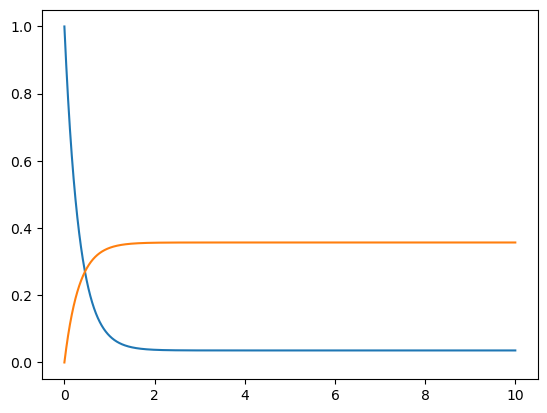

In [84]:
S_t=[]
T_t=[]
i=0
while i<len(t):
    S_t.append(27/28*m.e**(-3.1*t[i])+1/28*m.e**(-0.3*t[1]))
    T_t.append(-10/28*m.e**(-3.1*t[i])+10/28*m.e**(-0.3*t[1]))
    i+=1
plt.plot(t,S_t)
plt.plot(t,T_t)


#### b) Obtenção da solução analítica

Ficou curioso(a) sobre como chegar nessas soluções algébricas? Aguarde, em Matemática da Variação retomaremos esse mesmo modelo!

Porém, caso tenha curiosidade, saiba um pouco mais sobre o processo lendo o texto a seguir.

Podemos reescrever as equações diferenciais do nosso sistema na forma matricial. Confira se a multiplicação das matrizes abaixo está de acordo com as equações diferenciais que você descreveu no **Item 1a**:


$$
\begin{bmatrix}
    \frac{dS}{dt}\\
    \frac{dT}{dt}    
\end{bmatrix}
=
\begin{bmatrix}
    -3 & 0,27\\
    1 & -0,4
\end{bmatrix}
\cdot
\begin{bmatrix}
    S\\
    T    
\end{bmatrix}
$$


Na equação matricial acima, temos uma matriz $2\times 2$ que relaciona as derivadas de $S$ e $T$ com as próprias variáveis $S$ e $T$. No código abaixo, estamos declarando essa matriz numa estrutura de dados do Python denominada **matrix**. A partir daí, executamos uma linha de código que resulta em dois valores. Note que esses valores são exatamente os fatores multiplicativos nos expoentes das soluções do **Item 4a**. Esses são os famosos autovalores da matriz:

<center>
$\begin{bmatrix} -3 & 0,27\\1 & -0,4 \end{bmatrix}$
    </center>

Mas, o que são autovalores? Bom, isso você vai aprender em MatVar! Mantenha-se curioso(a) até lá!

In [ ]:
# Importa bibliotecas adicionais necessárias
from numpy import linalg
from numpy import matrix

# Cria a matriz A
A = matrix([[-3,0.27],[1,-0.4]])
print("Nossa matriz é:\n", A)

# Calcula e printa os autovalores da matriz A
autovalores = linalg.eig(A)[0]
print("Os autovalores da matriz são: %.2f" %(autovalores)[0], "e %.2f" %(autovalores)[1])